# Authors by period — 3-period final corpus

One figure only. Stacked bars: authors grouped into three conventional
historical windows, each bar showing `n_works · n_pages` of
Greek-world content by that author.

**Filters applied**

1. `selected_english_translation == 1` (one English translation per work)
2. Author has a valid `author_impact_date`
3. Drop mythic / tragic / speculative works (`factuality == 1`)
4. **Historians: keep only works whose polities are _entirely_ inside
   the Greek world.** A work is dropped if *any* of its
   `mentioned_polities_in_work` entries maps to a non-Greek group
   (Roman, Persian, or Ancient Near East) — even if a Greek polity
   also appears. This removes e.g. Herodotus's *Histories*
   (Persian + ANE alongside Greek), Plutarch's *Alexander* and
   *Themistocles* (Greek + Persian), all the *synkrisis* comparison
   pieces (Greek + Roman), the *Roman Lives*, Appian's *Roman
   History*, Josephus's entire corpus, and Xenophon's *Cyropaedia*.
5. Drop the New Testament
6. Drop `Unknown` (unattributed works)

Pseudo-Plutarch and Pseudo-Lucian are **kept**. `Lucian` and
`Lucian of Samosata` are merged (same `author_code = tlg0062`), and the
stray `tlg0061` row labelled `Lucian of Samosata` is restored to
`Pseudo-Lucian`.

**Sources**
- `data/clean/perseus/perseus_works_wikidata.tsv`
- `data/clean/final/works_factuality_v18.tsv`
- `data/clean/classifications/works_polity_time_mapping_v2.json` (for the Greek-world filter)

## 1. Setup

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

META_TSV     = Path('../data/clean/perseus/perseus_works_wikidata.tsv')
FACT_TSV     = Path('../data/clean/final/works_factuality_v18.tsv')
MAPPING_JSON = Path('../data/clean/classifications/works_polity_time_mapping_v2.json')

# Inclusive lower, exclusive upper; final period closed on 230 CE.
PERIODS_3 = [
    ('Early Classical\n(500–404 BCE)',      -500, -404),
    ('Late Classical\n(404 BCE – 31 BCE)',  -404,  -31),
    ('Early Imperial\n(31 BCE – 230 CE)',    -31,  231),
]

# Canonical author labels keyed by Perseus author_code. Fixes the
# inconsistent <author> tag in the Perseus TEI XML files.
CANONICAL_AUTHOR = {
    'tlg0062': 'Lucian of Samosata',
    'tlg0061': 'Pseudo-Lucian',
}

# Mirror of POLITY_TO_GROUP from 02_historians_time_coverage.ipynb.
# Update both places together when a new polity label appears upstream.
POLITY_TO_GROUP = {
    # ---------- Greek ----------
    'Classical Greek poleis':                       'Greek',
    'Classical Athens':                             'Greek',
    'Classical Sparta':                             'Greek',
    'Classical Sparta and Peloponnesian League':    'Greek',
    'Classical Thebes':                             'Greek',
    'Classical Greek mercenary polis-world':        'Greek',
    'Archaic Greek poleis':                         'Greek',
    'Archaic Athens (Solonic)':                     'Greek',
    'Archaic Sparta':                               'Greek',
    'Greek philosophical tradition (pan-Hellenic)': 'Greek',
    'Hellenistic Greek philosophical schools':      'Greek',
    'Hellenistic Mediterranean':                    'Greek',
    'Hellenistic Kingdoms':                         'Greek',
    'Hellenistic kingdoms':                         'Greek',
    'Hellenistic Athens':                           'Greek',
    'Hellenistic Sparta':                           'Greek',
    'Hellenistic East':                             'Greek',
    'Macedonian Empire':                            'Greek',
    'Macedonian kingdom':                           'Greek',
    'Macedonian Empire (Successors)':               'Greek',
    'Diadochi Successor States':                    'Greek',
    'Antigonid Dynasty':                            'Greek',
    'Seleucid Empire':                              'Greek',
    'Ptolemaic Kingdom':                            'Greek',
    'Achaean League':                               'Greek',
    'Syracuse':                                     'Greek',
    'Syracuse (Hiero I)':                           'Greek',
    'Sicyon':                                       'Greek',
    'Epirus':                                       'Greek',
    'Corinth':                                      'Greek',
    'Greece':                                       'Greek',
    'Asia Minor':                                   'Greek',
    'Illyrian kingdoms':                            'Greek',
    'Mythological Athens':                          'Greek',
    'Mythological Greece':                          'Greek',
    'Mythological Greece (Odyssey)':                'Greek',

    # ---------- Roman ----------
    'Roman Empire':                                 'Roman',
    'Roman Empire (Year of the Four Emperors)':     'Roman',
    'Roman Empire (Flavian)':                       'Roman',
    'Roman Empire (antiquarian)':                   'Roman',
    'Late Roman Republic':                          'Roman',
    'Middle Roman Republic':                        'Roman',
    'Early Roman Republic':                         'Roman',
    'Roman Republic':                               'Roman',
    'Roman Kingdom':                                'Roman',
    'Early Roman Kingdom':                          'Roman',
    'Rome':                                         'Roman',
    'Rome (antiquarian)':                           'Roman',
    'Italy':                                        'Roman',
    'Italic peoples':                               'Roman',
    'Samnite League':                               'Roman',
    'Volscians':                                    'Roman',
    'Gallic tribes':                                'Roman',
    'Carthage':                                     'Roman',
    'Kingdom of Numidia':                           'Roman',
    'Lusitania':                                    'Roman',
    'Celtiberian tribes':                           'Roman',
    'Pontic kingdom (Mithridates VI)':              'Roman',

    # ---------- Greco-Roman ----------
    'Roman Empire (Hellenic culture)':              'Greco-Roman',
    'Roman Empire (Greece)':                        'Greco-Roman',
    'Roman Empire (Greece and Thrace)':             'Greco-Roman',
    'Roman Empire (Hellenic intellectual world)':   'Greco-Roman',

    # ---------- Persian ----------
    'Achaemenid Empire':                            'Persian',
    'Achaemenid Empire (Cyrus the Great)':          'Persian',
    'Achaemenid Persia':                            'Persian',
    'Achaidmenid Empire':                           'Persian',   # typo in source
    'Lydia':                                        'Persian',

    # ---------- Ancient Near East ----------
    'Pharaonic Egypt':                              'Ancient Near East',
    'Pharaonic Egypt (religious-mythic)':           'Ancient Near East',
    'Ancient Israel / Second Temple Judaism':       'Ancient Near East',
    'Judea':                                        'Ancient Near East',
    'Ancient Near East (mythic)':                   'Ancient Near East',
}

GREEK_GROUPS = {'Greek', 'Greco-Roman'}

In [2]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'Helvetica',
    'font.size': 10,
})

BAR_COLOR  = '#3a6e8f'
EDGE_COLOR = 'white'
TEXT_DARK  = '#1a202c'
TEXT_MUTED = '#4a5568'

## 2. Load data and normalise author labels

In [3]:
meta_raw = pd.read_csv(META_TSV, sep='\t')
fact_raw = pd.read_csv(FACT_TSV, sep='\t')[['perseus_id', 'factuality']]

# Collapse variant <author> strings to one canonical label per author_code.
for code, label in CANONICAL_AUTHOR.items():
    meta_raw.loc[meta_raw['author_code'] == code, 'perseus_author'] = label

print(f'Meta:       {len(meta_raw):,} works from {META_TSV.name}')
print(f'Factuality: {len(fact_raw):,} rows  from {FACT_TSV.name}')

Meta:       1,096 works from perseus_works_wikidata.tsv
Factuality: 391 rows  from works_factuality_v18.tsv


## 3. Apply filters

In [4]:
df = meta_raw[meta_raw['selected_english_translation'] == 1].copy()
steps = [('Selected English', len(df))]

df['year'] = pd.to_numeric(df['author_impact_date'], errors='coerce')
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)
df['n_pages'] = pd.to_numeric(df['n_pages'], errors='coerce').fillna(0).astype(int)
steps.append(('Require author year', len(df)))

df = df.merge(fact_raw, on='perseus_id', how='left')
df = df[df['factuality'] != 1].copy()
steps.append(('Drop factuality == 1 (mythic/tragic/speculative)', len(df)))

# Strict Greek-world filter for historians: keep a historian work only
# if ALL its polities fall in GREEK_GROUPS. Any single non-Greek
# polity (Roman, Persian, ANE) drops the whole work.
with MAPPING_JSON.open() as f:
    polity_mapping = json.load(f)

unmapped = set()
all_greek = {}     # file_id -> True iff every polity in the work is Greek/Greco-Roman
for file_id, v in polity_mapping.items():
    polities = [p.strip() for p in
                (v.get('mentioned_polities_in_work') or '').split(';')
                if p.strip()]
    groups = set()
    for p in polities:
        g = POLITY_TO_GROUP.get(p)
        if g is None:
            unmapped.add(p)
        else:
            groups.add(g)
    all_greek[file_id] = bool(groups) and groups.issubset(GREEK_GROUPS)
assert not unmapped, f'Unmapped polities: {sorted(unmapped)}'

df['greek_only'] = df['file_id'].map(all_greek).fillna(False)
n_before = len(df)
df = df[(df['historian'] != 1) | df['greek_only']].copy()
steps.append(('Historians: keep only entirely-Greek-world works '
              f'(dropped {n_before - len(df)} historian works)', len(df)))

author_norm = df['perseus_author'].astype(str).str.strip().str.lower()
df = df[~author_norm.isin({'new testament', 'unknown'})].copy()
steps.append(('Drop New Testament and Unknown', len(df)))

print('Row count after each step:')
for label, n in steps:
    print(f'  {label:<72s}  {n:,}')
print(f'\nFinal corpus: {len(df)} works | '
      f'{df["perseus_author"].nunique()} authors | '
      f'{df["n_pages"].sum():,} pages')

Row count after each step:
  Selected English                                                          581
  Require author year                                                       581
  Drop factuality == 1 (mythic/tragic/speculative)                          508
  Historians: keep only entirely-Greek-world works (dropped 122 historian works)  386
  Drop New Testament and Unknown                                            356

Final corpus: 356 works | 33 authors | 20,478 pages


In [5]:
def assign_period(year):
    for label, lo, hi in PERIODS_3:
        if lo <= year < hi:
            return label
    return None

df['period'] = df['year'].apply(assign_period)
dropped = df['period'].isna().sum()
df = df[df['period'].notna()].copy()

print(f'Dropped (outside 500 BCE – 230 CE): {dropped}')
print(df['period'].value_counts().reindex([p[0] for p in PERIODS_3]))

Dropped (outside 500 BCE – 230 CE): 0
period
Early Classical\n(500–404 BCE)         75
Late Classical\n(404 BCE – 31 BCE)    167
Early Imperial\n(31 BCE – 230 CE)     114
Name: count, dtype: int64


## 4. Aggregate by author × period

In [6]:
by_author = (df.groupby(['period', 'perseus_author'])
               .agg(n_works=('file_id', 'count'),
                    total_pages=('n_pages', 'sum'))
               .reset_index())

period_totals = (by_author.groupby('period')['perseus_author']
                           .nunique().rename('n_authors'))

print('Distinct authors per period:')
print(period_totals.to_string())

Distinct authors per period:
period
Early Classical\n(500–404 BCE)         6
Early Imperial\n(31 BCE – 230 CE)     15
Late Classical\n(404 BCE – 31 BCE)    12


## 5. Figure — authors stacked by period

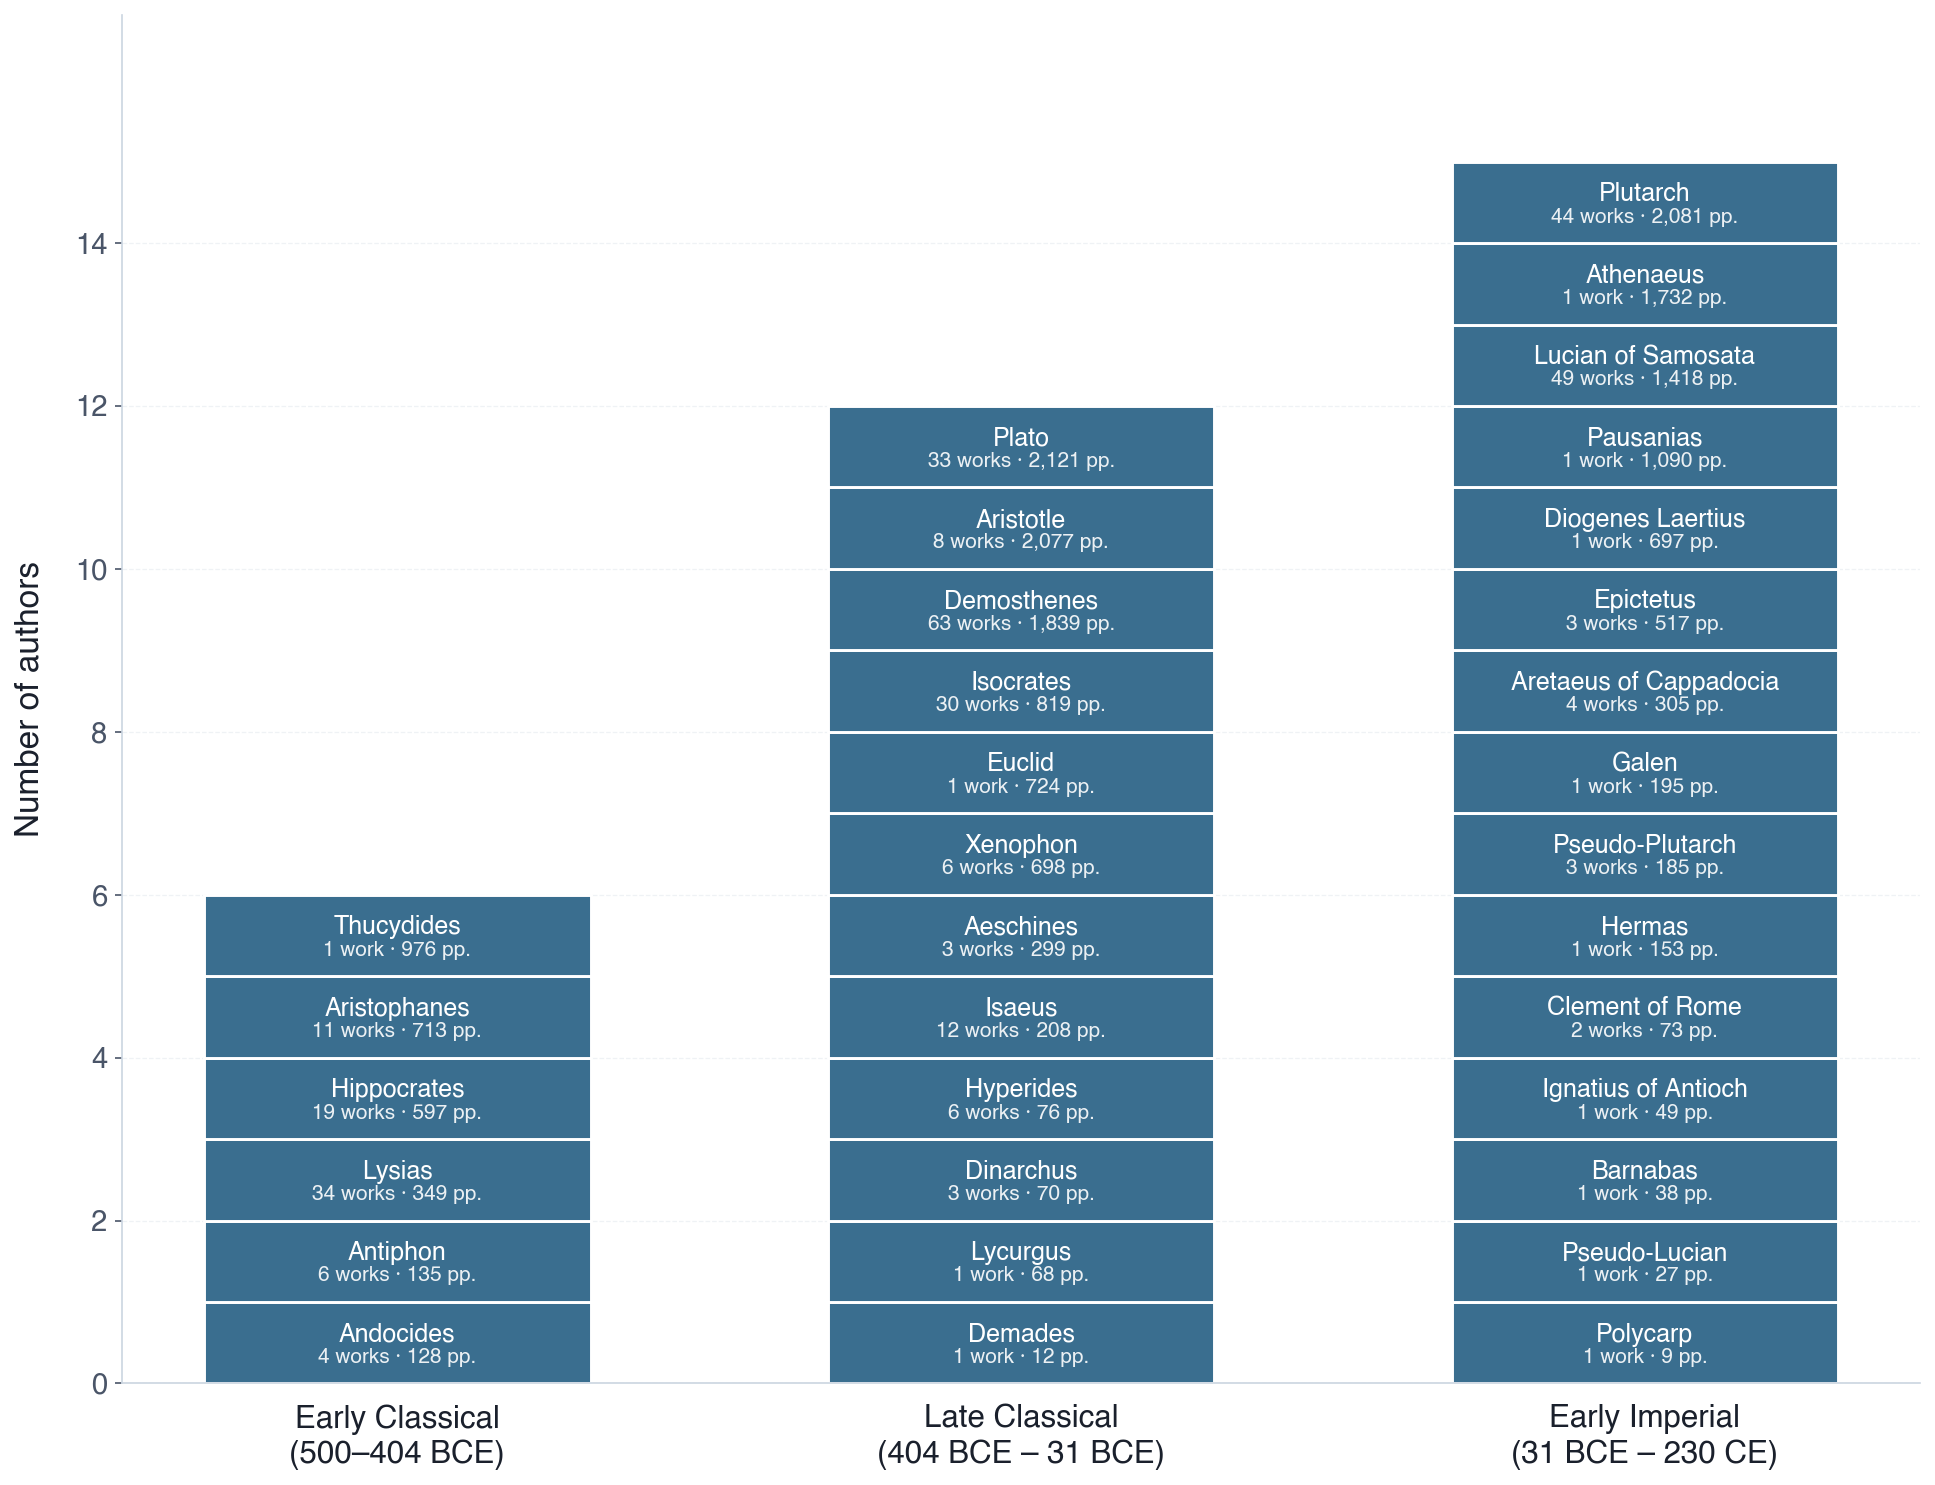

In [7]:
period_order = [p[0] for p in PERIODS_3]
max_height = int(period_totals.max())
bar_width = 0.62

fig, ax = plt.subplots(figsize=(13, 10))

for x, period in enumerate(period_order):
    authors = (by_author[by_author['period'] == period]
               .sort_values('total_pages', ascending=True)
               .reset_index(drop=True))

    for i, row in authors.iterrows():
        ax.bar(x, 1, bottom=i, width=bar_width,
               color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=1.4)
        n_w = int(row['n_works']); n_p = int(row['total_pages'])
        works_lbl = f'{n_w} work' + ('' if n_w == 1 else 's')
        pages_lbl = f'{n_p:,} pp.'
        ax.text(x, i + 0.60, row['perseus_author'],
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')
        ax.text(x, i + 0.32, f'{works_lbl} · {pages_lbl}',
                ha='center', va='center',
                fontsize=10, color='white', alpha=0.9)

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order, fontsize=15, color=TEXT_DARK)
ax.set_ylabel('Number of authors', fontsize=16, color=TEXT_DARK, labelpad=14)
ax.set_ylim(0, max_height + 1.8)
ax.set_yticks(range(0, max_height + 1, 2))
ax.tick_params(axis='y', labelsize=14, color=TEXT_MUTED, labelcolor=TEXT_MUTED)
ax.tick_params(axis='x', labelsize=15, length=0, pad=10)

for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
for s in ('left', 'bottom'):
    ax.spines[s].set_color('#cbd5e0')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.6, color='#cbd5e0')
ax.set_axisbelow(True)

fig.tight_layout()